In [1]:
# ============================================================
# CELL 1: SETUP & IMPORTS
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Στυλ γραφημάτων
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print("Imports ολοκληρώθηκαν")

Mounted at /content/drive
Imports ολοκληρώθηκαν


In [2]:
# ============================================================
# CELL 2: ΦΟΡΤΩΣΗ ΚΑΙ ΣΥΓΧΡΟΝΙΣΜΟΣ ΟΛΩΝ ΤΩΝ DATASETS
# ============================================================

paths = {
    'BESS':        '/content/drive/MyDrive/Final_RUn/239-Site_DKA_Totals-BESS.csv',
    'Site_Demand': '/content/drive/MyDrive/Final_RUn/240-Site_DKA_Totals-Site_Demand.csv',
    'PV':          '/content/drive/MyDrive/Final_RUn/241-Site_DKA_Totals-PV.csv',
    'Grid':        '/content/drive/MyDrive/Final_RUn/242-Site_DKA_Totals-Grid.csv'
}

# Φόρτωση
datasets = {}
for name, path in paths.items():
    df_temp = pd.read_csv(path, engine='python', on_bad_lines='skip')
    df_temp['timestamp'] = pd.to_datetime(df_temp['timestamp'], errors='coerce')
    df_temp = df_temp.dropna(subset=['timestamp'])
    df_temp = df_temp.set_index('timestamp').sort_index()
    datasets[name] = df_temp
    print(f"{name}: {len(df_temp):,} γραμμές")

# Κοινό date range
common_start = max(df.index.min() for df in datasets.values())
common_end = min(df.index.max() for df in datasets.values())

print(f"\nΚοινό date range: {common_start} έως {common_end}")
print(f"Διάρκεια: {(common_end - common_start).days} ημέρες")

# Sync σε κοινή χρονική περίοδο
for name in datasets:
    datasets[name] = datasets[name].loc[common_start:common_end]
    print(f"{name} μετά sync: {len(datasets[name]):,} γραμμές")

BESS: 250,740 γραμμές
Site_Demand: 182,349 γραμμές
PV: 182,295 γραμμές
Grid: 182,289 γραμμές

Κοινό date range: 2023-12-07 13:20:00 έως 2025-09-04 12:10:00
Διάρκεια: 636 ημέρες
BESS μετά sync: 182,324 γραμμές
Site_Demand μετά sync: 182,346 γραμμές
PV μετά sync: 182,293 γραμμές
Grid μετά sync: 182,289 γραμμές


In [3]:
# ============================================================
# CELL 3: ΔΗΜΙΟΥΡΓΙΑ ENIAIOY DATAFRAME ΓΙΑ EDA
# ============================================================

# Παίρνουμε μόνο τα Active_Power από κάθε dataset (αυτά διαφέρουν)
# και τα weather data μία φορά (από PV)

# Κύριες μεταβλητές από κάθε source
df_eda = pd.DataFrame(index=datasets['PV'].index)

df_eda['PV_Power']           = datasets['PV']['Active_Power']
df_eda['Site_Demand']        = datasets['Site_Demand']['Active_Power']
df_eda['Grid_Power']         = datasets['Grid']['Active_Power']
df_eda['BESS_Power']         = datasets['BESS']['Active_Power']
df_eda['BESS_SoC']           = datasets['BESS']['State_of_Charge']

# Weather data (από PV - είναι ίδια σε όλα)
weather_cols = [
    'Weather_Temperature_Celsius',
    'Weather_Relative_Humidity',
    'Global_Horizontal_Radiation',
    'Diffuse_Horizontal_Radiation',
    'Radiation_Global_Tilted',
    'Radiation_Diffuse_Tilted',
    'Weather_Daily_Rainfall'
]

for col in weather_cols:
    df_eda[col] = datasets['PV'][col]

# Time-based features
df_eda['hour']        = df_eda.index.hour
df_eda['day_of_week'] = df_eda.index.dayofweek  # 0=Δευτέρα, 6=Κυριακή
df_eda['month']       = df_eda.index.month
df_eda['is_weekend']  = (df_eda['day_of_week'] >= 5).astype(int)

print(f"Συνολικό dataframe: {df_eda.shape}")
print(f"\nΣτήλες:")
for col in df_eda.columns:
    print(f"  - {col}")

Συνολικό dataframe: (182293, 16)

Στήλες:
  - PV_Power
  - Site_Demand
  - Grid_Power
  - BESS_Power
  - BESS_SoC
  - Weather_Temperature_Celsius
  - Weather_Relative_Humidity
  - Global_Horizontal_Radiation
  - Diffuse_Horizontal_Radiation
  - Radiation_Global_Tilted
  - Radiation_Diffuse_Tilted
  - Weather_Daily_Rainfall
  - hour
  - day_of_week
  - month
  - is_weekend


In [4]:
# ============================================================
# CELL 4: BASIC CLEANING (μόνο τα προφανή προβλήματα)
# ============================================================

print("="*70)
print(" BASIC CLEANING")
print("="*70)

initial = len(df_eda)

# 1. Site_Demand δεν μπορεί να είναι αρνητικό (φυσική σημασία)
neg_demand = (df_eda['Site_Demand'] < 0).sum()
print(f"Αρνητικές τιμές Site_Demand: {neg_demand} -> NaN")
df_eda.loc[df_eda['Site_Demand'] < 0, 'Site_Demand'] = np.nan

# 2. PV_Power δεν μπορεί να είναι αρνητικό σημαντικά
# (μικρές αρνητικές τιμές = inverter standby, οκ)
neg_pv = (df_eda['PV_Power'] < -10).sum()
print(f"Σημαντικά αρνητικές τιμές PV (<-10): {neg_pv} -> NaN")
df_eda.loc[df_eda['PV_Power'] < -10, 'PV_Power'] = np.nan
# Τις μικρές αρνητικές τις κάνουμε 0
df_eda.loc[df_eda['PV_Power'] < 0, 'PV_Power'] = 0

# 3. Humidity > 100% είναι μη φυσικό
high_hum = (df_eda['Weather_Relative_Humidity'] > 100).sum()
print(f"Humidity > 100%: {high_hum} -> clip στο 100")
df_eda['Weather_Relative_Humidity'] = df_eda['Weather_Relative_Humidity'].clip(0, 100)

# 4. SoC πρέπει να είναι 0-100%
soc_invalid = ((df_eda['BESS_SoC'] < 0) | (df_eda['BESS_SoC'] > 100)).sum()
print(f"Μη έγκυρες τιμές SoC: {soc_invalid} -> clip στο 0-100")
df_eda['BESS_SoC'] = df_eda['BESS_SoC'].clip(0, 100)

print(f"\nMissing values μετά basic cleaning:")
print(df_eda.isnull().sum())

 BASIC CLEANING
Αρνητικές τιμές Site_Demand: 1147 -> NaN
Σημαντικά αρνητικές τιμές PV (<-10): 0 -> NaN
Humidity > 100%: 3683 -> clip στο 100
Μη έγκυρες τιμές SoC: 0 -> clip στο 0-100

Missing values μετά basic cleaning:
PV_Power                        16934
Site_Demand                     18359
Grid_Power                      25488
BESS_Power                      17017
BESS_SoC                        31117
Weather_Temperature_Celsius     36289
Weather_Relative_Humidity       36285
Global_Horizontal_Radiation     36270
Diffuse_Horizontal_Radiation    36270
Radiation_Global_Tilted         32344
Radiation_Diffuse_Tilted        32344
Weather_Daily_Rainfall          36270
hour                                0
day_of_week                         0
month                               0
is_weekend                          0
dtype: int64


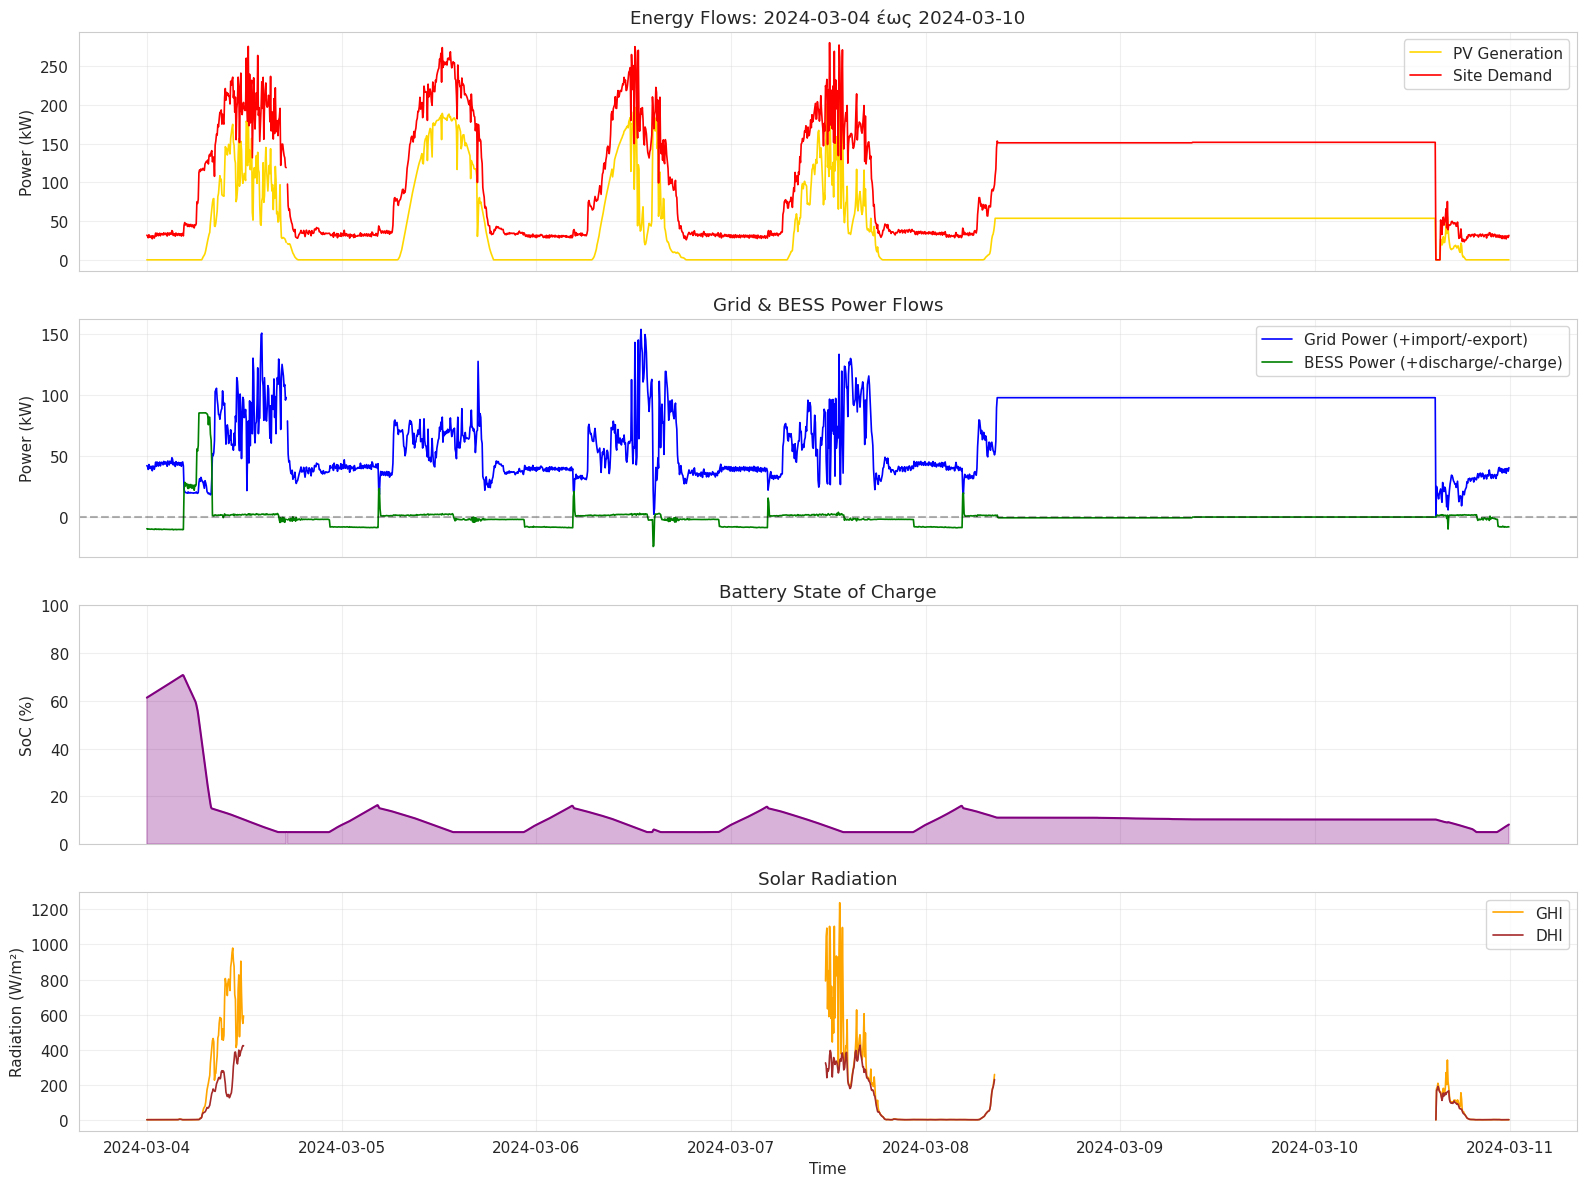

Γράφημα αποθηκεύτηκε: eda_timeseries_week.png


In [5]:
# ============================================================
# CELL 5: ΟΠΤΙΚΟΠΟΙΗΣΗ - TIME SERIES (1 εβδομάδα)
# ============================================================

# Διαλέγουμε μία τυπική εβδομάδα του 2024 (Μάρτιος, εκτός peak summer/winter)
sample_start = '2024-03-04'  # Δευτέρα
sample_end = '2024-03-10'    # Κυριακή

df_sample = df_eda.loc[sample_start:sample_end]

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

# 1. Energy Flows
axes[0].plot(df_sample.index, df_sample['PV_Power'], label='PV Generation', color='gold', linewidth=1.2)
axes[0].plot(df_sample.index, df_sample['Site_Demand'], label='Site Demand', color='red', linewidth=1.2)
axes[0].set_ylabel('Power (kW)')
axes[0].set_title(f'Energy Flows: {sample_start} έως {sample_end}')
axes[0].legend(loc='upper right')
axes[0].grid(alpha=0.3)

# 2. Grid & BESS
axes[1].plot(df_sample.index, df_sample['Grid_Power'], label='Grid Power (+import/-export)',
             color='blue', linewidth=1.2)
axes[1].plot(df_sample.index, df_sample['BESS_Power'], label='BESS Power (+discharge/-charge)',
             color='green', linewidth=1.2)
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[1].set_ylabel('Power (kW)')
axes[1].set_title('Grid & BESS Power Flows')
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)

# 3. SoC
axes[2].plot(df_sample.index, df_sample['BESS_SoC'], color='purple', linewidth=1.5)
axes[2].fill_between(df_sample.index, df_sample['BESS_SoC'], alpha=0.3, color='purple')
axes[2].set_ylabel('SoC (%)')
axes[2].set_title('Battery State of Charge')
axes[2].set_ylim(0, 100)
axes[2].grid(alpha=0.3)

# 4. Weather (radiation)
axes[3].plot(df_sample.index, df_sample['Global_Horizontal_Radiation'],
             label='GHI', color='orange', linewidth=1.2)
axes[3].plot(df_sample.index, df_sample['Diffuse_Horizontal_Radiation'],
             label='DHI', color='brown', linewidth=1.2)
axes[3].set_ylabel('Radiation (W/m²)')
axes[3].set_xlabel('Time')
axes[3].set_title('Solar Radiation')
axes[3].legend(loc='upper right')
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/eda_timeseries_week.png', dpi=120, bbox_inches='tight')
plt.show()

print("Γράφημα αποθηκεύτηκε: eda_timeseries_week.png")

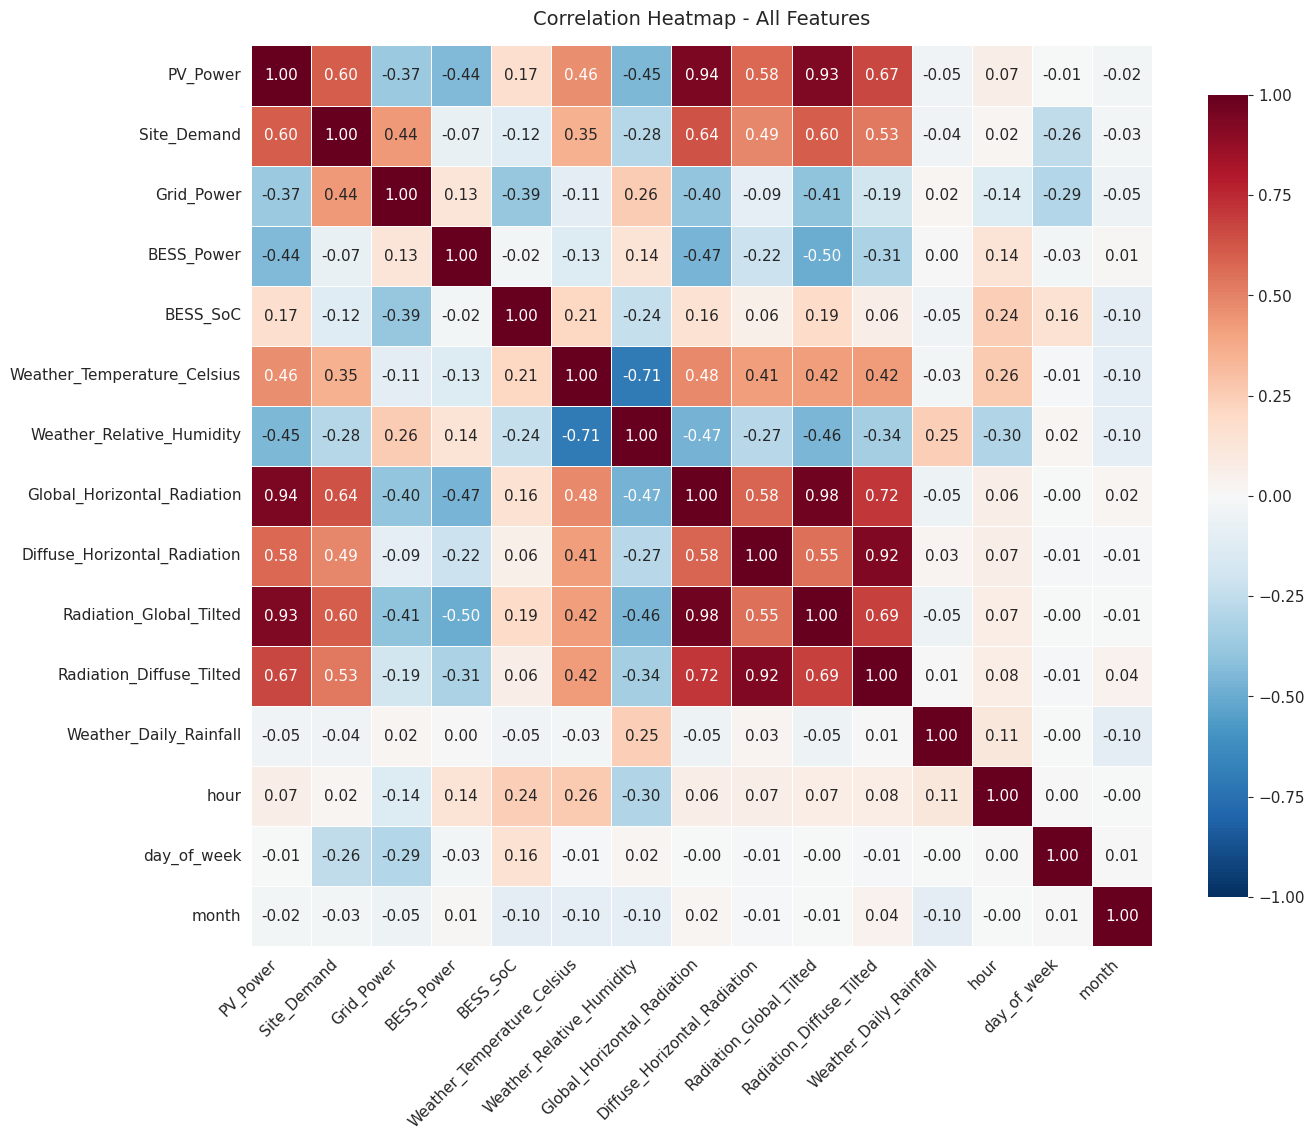

Γράφημα αποθηκεύτηκε: eda_correlation_heatmap.png


In [6]:
# ============================================================
# CELL 6: HEATMAP CORRELATIONS - ΚΥΡΙΑ FEATURES
# ============================================================

# Επιλέγουμε αριθμητικά features (όχι time features για τώρα)
correlation_cols = [
    'PV_Power', 'Site_Demand', 'Grid_Power', 'BESS_Power', 'BESS_SoC',
    'Weather_Temperature_Celsius', 'Weather_Relative_Humidity',
    'Global_Horizontal_Radiation', 'Diffuse_Horizontal_Radiation',
    'Radiation_Global_Tilted', 'Radiation_Diffuse_Tilted',
    'Weather_Daily_Rainfall', 'hour', 'day_of_week', 'month'
]

corr_matrix = df_eda[correlation_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap - All Features', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/eda_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

print("Γράφημα αποθηκεύτηκε: eda_correlation_heatmap.png")

In [7]:
# ============================================================
# CELL 7: ΣΥΣΧΕΤΙΣΕΙΣ - TARGETS vs ALL FEATURES
# ============================================================

# Δύο targets: Site_Demand και PV_Power
targets = ['Site_Demand', 'PV_Power']

print("="*70)
print(" CORRELATIONS WITH TARGET VARIABLES")
print("="*70)

for target in targets:
    print(f"\n--- {target} ---")
    corrs = df_eda[correlation_cols].corr()[target].drop(target).sort_values(
        key=abs, ascending=False)

    for feature, corr in corrs.items():
        bar_length = int(abs(corr) * 30)
        bar = '█' * bar_length
        sign = '+' if corr > 0 else '-'
        print(f"  {feature:<35} {sign}{abs(corr):.3f} {bar}")

 CORRELATIONS WITH TARGET VARIABLES

--- Site_Demand ---
  Global_Horizontal_Radiation         +0.636 ███████████████████
  Radiation_Global_Tilted             +0.605 ██████████████████
  PV_Power                            +0.602 ██████████████████
  Radiation_Diffuse_Tilted            +0.529 ███████████████
  Diffuse_Horizontal_Radiation        +0.485 ██████████████
  Grid_Power                          +0.436 █████████████
  Weather_Temperature_Celsius         +0.354 ██████████
  Weather_Relative_Humidity           -0.282 ████████
  day_of_week                         -0.255 ███████
  BESS_SoC                            -0.118 ███
  BESS_Power                          -0.071 ██
  Weather_Daily_Rainfall              -0.040 █
  month                               -0.031 
  hour                                +0.023 

--- PV_Power ---
  Global_Horizontal_Radiation         +0.945 ████████████████████████████
  Radiation_Global_Tilted             +0.930 ███████████████████████████
  Radi

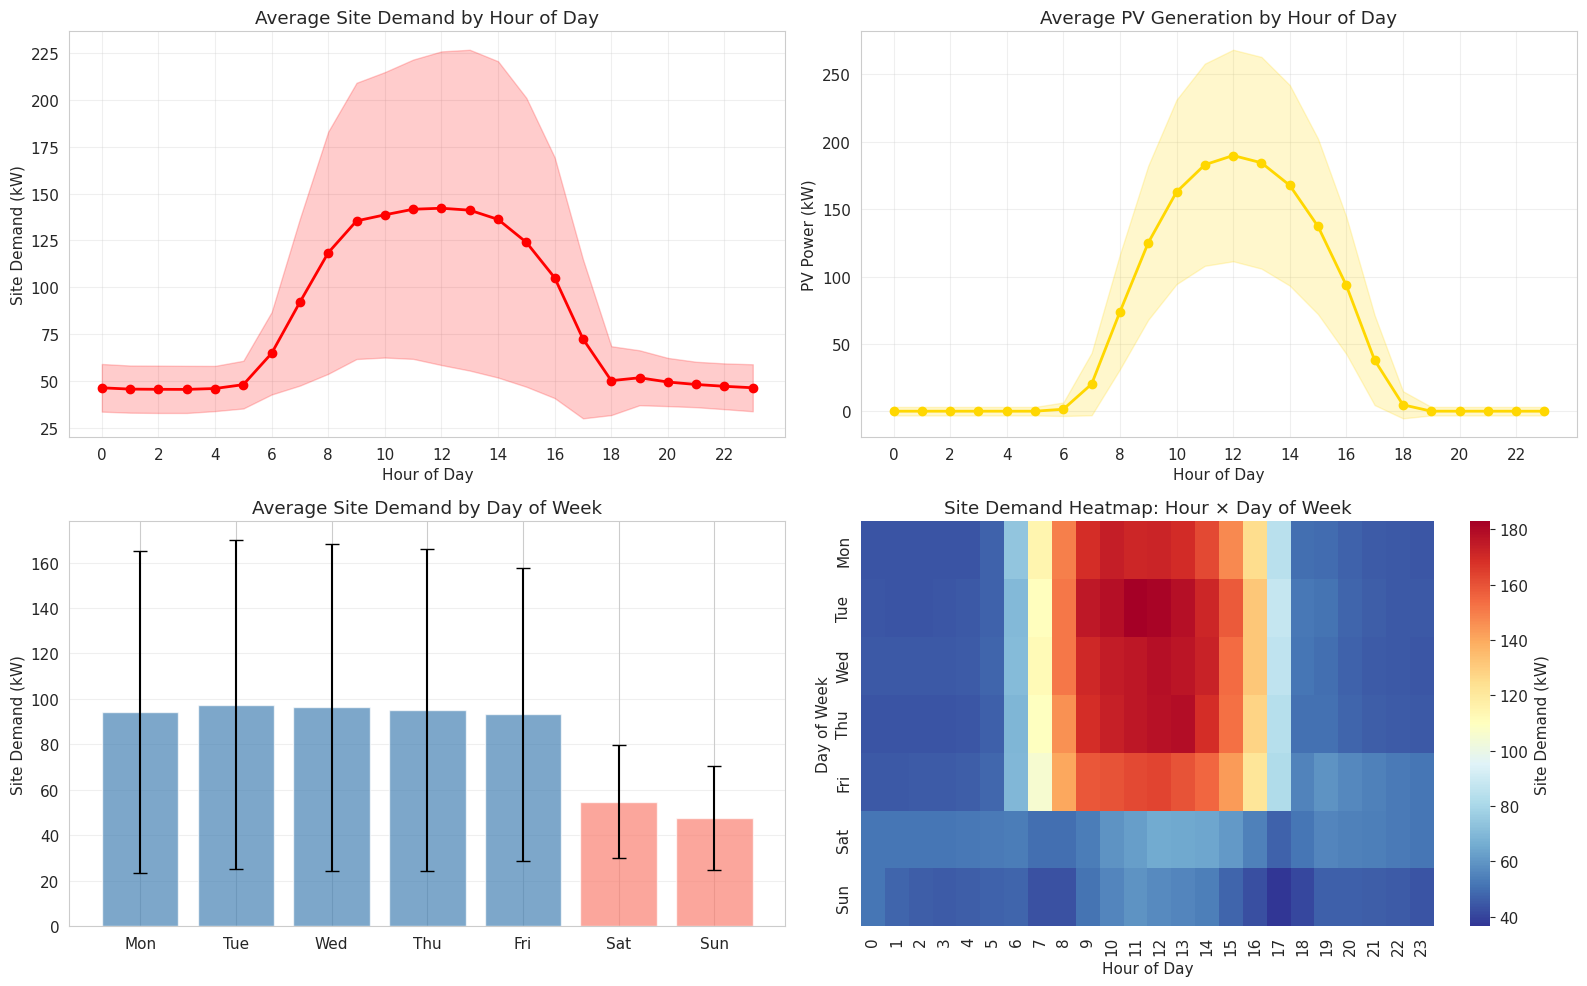


 QUANTITATIVE INSIGHTS

Site Demand:
  Min hourly avg:  45.6 kW (hour 3)
  Max hourly avg:  142.2 kW (hour 12)
  Peak/off ratio:  3.1x

  Weekday avg:     95.3 kW
  Weekend avg:     51.3 kW
  Ratio:           1.86x


In [8]:
# ============================================================
# CELL 8: HOURLY & WEEKLY PATTERNS ANALYSIS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Site_Demand by hour of day
hourly_demand = df_eda.groupby('hour')['Site_Demand'].agg(['mean', 'std'])
axes[0, 0].plot(hourly_demand.index, hourly_demand['mean'],
                marker='o', color='red', linewidth=2)
axes[0, 0].fill_between(hourly_demand.index,
                         hourly_demand['mean'] - hourly_demand['std'],
                         hourly_demand['mean'] + hourly_demand['std'],
                         alpha=0.2, color='red')
axes[0, 0].set_xlabel('Hour of Day')
axes[0, 0].set_ylabel('Site Demand (kW)')
axes[0, 0].set_title('Average Site Demand by Hour of Day')
axes[0, 0].set_xticks(range(0, 24, 2))
axes[0, 0].grid(alpha=0.3)

# 2. PV_Power by hour of day
hourly_pv = df_eda.groupby('hour')['PV_Power'].agg(['mean', 'std'])
axes[0, 1].plot(hourly_pv.index, hourly_pv['mean'],
                marker='o', color='gold', linewidth=2)
axes[0, 1].fill_between(hourly_pv.index,
                         hourly_pv['mean'] - hourly_pv['std'],
                         hourly_pv['mean'] + hourly_pv['std'],
                         alpha=0.2, color='gold')
axes[0, 1].set_xlabel('Hour of Day')
axes[0, 1].set_ylabel('PV Power (kW)')
axes[0, 1].set_title('Average PV Generation by Hour of Day')
axes[0, 1].set_xticks(range(0, 24, 2))
axes[0, 1].grid(alpha=0.3)

# 3. Site_Demand by day of week
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_demand = df_eda.groupby('day_of_week')['Site_Demand'].agg(['mean', 'std'])
colors_dow = ['steelblue']*5 + ['salmon']*2  # weekday vs weekend
axes[1, 0].bar(dow_labels, dow_demand['mean'],
               yerr=dow_demand['std'], color=colors_dow,
               alpha=0.7, capsize=5)
axes[1, 0].set_ylabel('Site Demand (kW)')
axes[1, 0].set_title('Average Site Demand by Day of Week')
axes[1, 0].grid(alpha=0.3, axis='y')

# 4. Heatmap: Demand by hour and day_of_week
pivot = df_eda.pivot_table(values='Site_Demand', index='day_of_week',
                            columns='hour', aggfunc='mean')
sns.heatmap(pivot, ax=axes[1, 1], cmap='RdYlBu_r',
            cbar_kws={'label': 'Site Demand (kW)'},
            yticklabels=dow_labels)
axes[1, 1].set_xlabel('Hour of Day')
axes[1, 1].set_ylabel('Day of Week')
axes[1, 1].set_title('Site Demand Heatmap: Hour × Day of Week')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/eda_temporal_patterns.png', dpi=120, bbox_inches='tight')
plt.show()

# Στατιστικά
print(f"\n{'='*60}")
print(" QUANTITATIVE INSIGHTS")
print(f"{'='*60}")

print(f"\nSite Demand:")
print(f"  Min hourly avg:  {hourly_demand['mean'].min():.1f} kW (hour {hourly_demand['mean'].idxmin()})")
print(f"  Max hourly avg:  {hourly_demand['mean'].max():.1f} kW (hour {hourly_demand['mean'].idxmax()})")
print(f"  Peak/off ratio:  {hourly_demand['mean'].max()/hourly_demand['mean'].min():.1f}x")

weekday_avg = df_eda[df_eda['is_weekend'] == 0]['Site_Demand'].mean()
weekend_avg = df_eda[df_eda['is_weekend'] == 1]['Site_Demand'].mean()
print(f"\n  Weekday avg:     {weekday_avg:.1f} kW")
print(f"  Weekend avg:     {weekend_avg:.1f} kW")
print(f"  Ratio:           {weekday_avg/weekend_avg:.2f}x")

 OUTAGE / DATA QUALITY ANALYSIS
Ύποπτες παρατηρήσεις (12 διαδοχικές ίδιες τιμές): 1120 (0.61%)

 SEASONAL PATTERNS (Monthly Averages)
       PV_Power  Site_Demand  Weather_Temperature_Celsius  Global_Horizontal_Radiation
month                                                                                 
1          82.0         98.1                         31.7                        317.4
2          75.6        102.4                         30.8                        310.4
3          41.6         90.4                         26.6                        223.1
4          54.0         63.8                         17.9                        266.4
5          46.8         67.6                         14.2                        206.2
6          47.2         74.3                         12.2                        189.6
7          51.3         79.3                         11.1                        210.3
8          56.9         74.3                         16.2                        25

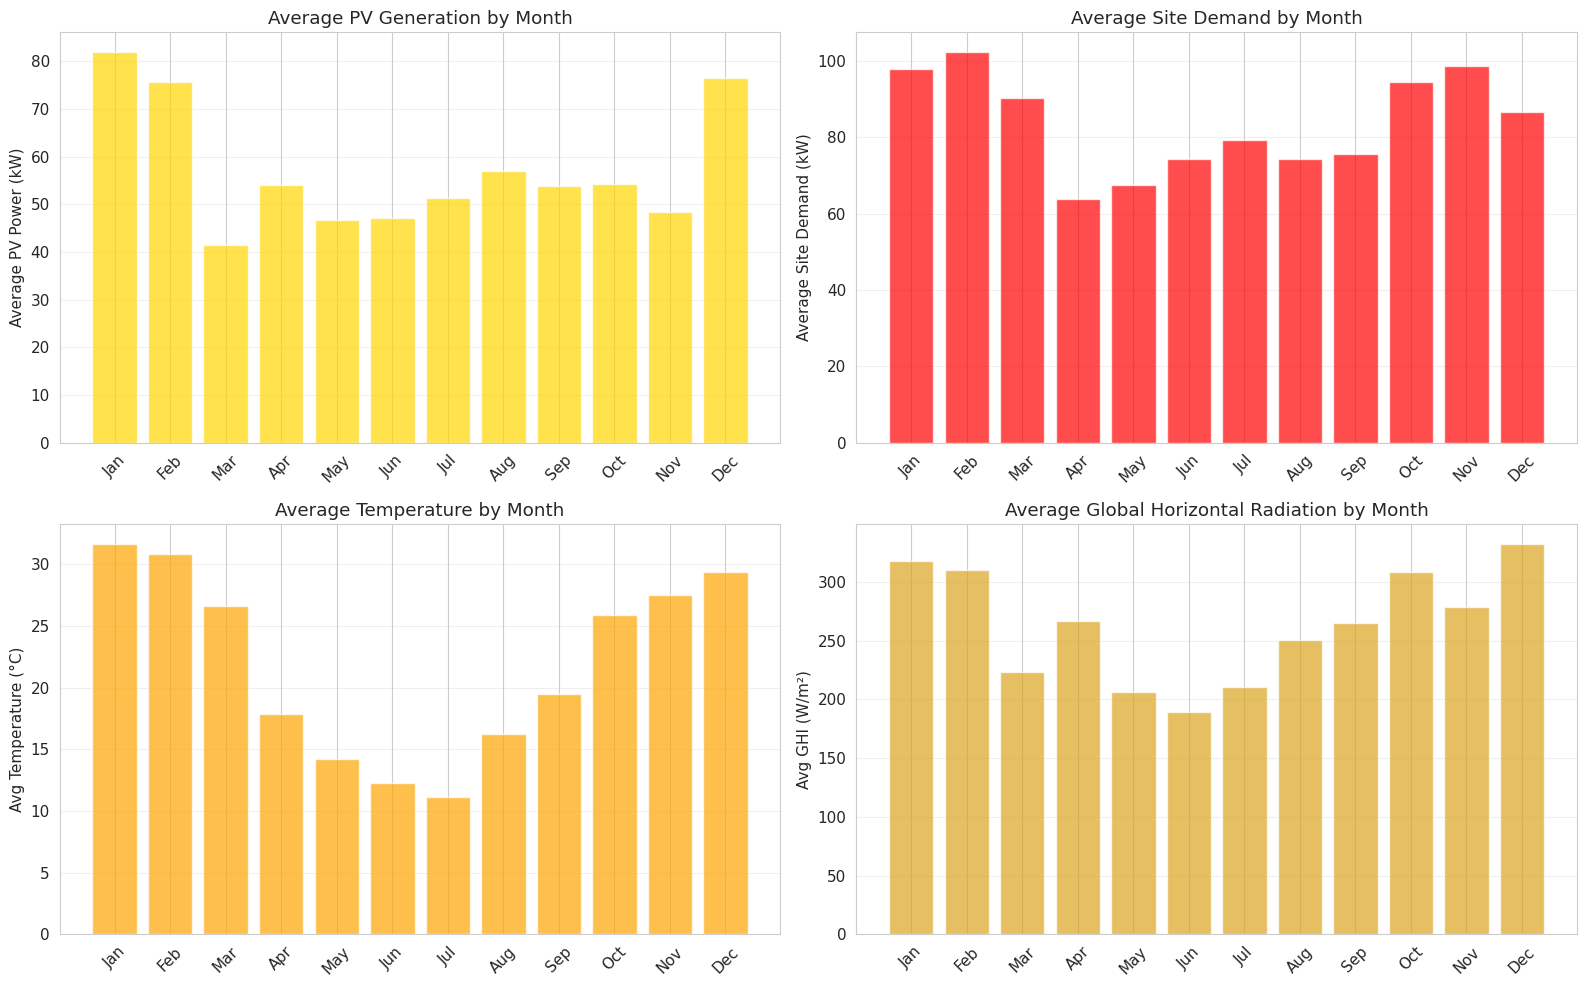


 DAILY DATA AVAILABILITY
Συνολικές ημέρες: 638
Ημέρες με < 200 records (από 288 αναμενόμενα): 17 (2.7%)
Ημέρες με 0 records: 3


In [9]:
# ============================================================
# CELL 9: OUTAGE DETECTION & SEASONAL PATTERNS
# ============================================================

# 1. Identify outage periods (long sequences of suspicious data)
print("="*70)
print(" OUTAGE / DATA QUALITY ANALYSIS")
print("="*70)

# Resample σε ωριαία βάση για καθαρότερη εικόνα
hourly = df_eda.resample('1H').mean()

# Έλεγχος για ύποπτες περιόδους:
# Ένα outage μοιάζει με: ίδια τιμή σε πολλές διαδοχικές ώρες
df_eda['demand_diff'] = df_eda['Site_Demand'].diff().abs()
suspicious = (df_eda['demand_diff'] < 0.01).rolling(window=12).sum() >= 11
suspicious_count = suspicious.sum()
print(f"Ύποπτες παρατηρήσεις (12 διαδοχικές ίδιες τιμές): {suspicious_count} ({suspicious_count/len(df_eda)*100:.2f}%)")

# 2. Monthly aggregations
monthly_stats = df_eda.groupby('month').agg({
    'PV_Power': 'mean',
    'Site_Demand': 'mean',
    'Weather_Temperature_Celsius': 'mean',
    'Global_Horizontal_Radiation': 'mean'
})
print(f"\n{'='*70}")
print(" SEASONAL PATTERNS (Monthly Averages)")
print(f"{'='*70}")
print(monthly_stats.round(1).to_string())

# 3. Visualize seasonal patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# PV by month
axes[0, 0].bar(monthly_stats.index, monthly_stats['PV_Power'], color='gold', alpha=0.7)
axes[0, 0].set_xticks(range(1, 13))
axes[0, 0].set_xticklabels(month_labels, rotation=45)
axes[0, 0].set_ylabel('Average PV Power (kW)')
axes[0, 0].set_title('Average PV Generation by Month')
axes[0, 0].grid(alpha=0.3, axis='y')

# Demand by month
axes[0, 1].bar(monthly_stats.index, monthly_stats['Site_Demand'], color='red', alpha=0.7)
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].set_xticklabels(month_labels, rotation=45)
axes[0, 1].set_ylabel('Average Site Demand (kW)')
axes[0, 1].set_title('Average Site Demand by Month')
axes[0, 1].grid(alpha=0.3, axis='y')

# Temperature by month
axes[1, 0].bar(monthly_stats.index, monthly_stats['Weather_Temperature_Celsius'],
               color='orange', alpha=0.7)
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].set_xticklabels(month_labels, rotation=45)
axes[1, 0].set_ylabel('Avg Temperature (°C)')
axes[1, 0].set_title('Average Temperature by Month')
axes[1, 0].grid(alpha=0.3, axis='y')

# Radiation by month
axes[1, 1].bar(monthly_stats.index, monthly_stats['Global_Horizontal_Radiation'],
               color='goldenrod', alpha=0.7)
axes[1, 1].set_xticks(range(1, 13))
axes[1, 1].set_xticklabels(month_labels, rotation=45)
axes[1, 1].set_ylabel('Avg GHI (W/m²)')
axes[1, 1].set_title('Average Global Horizontal Radiation by Month')
axes[1, 1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/eda_seasonal.png', dpi=120, bbox_inches='tight')
plt.show()

# 4. Daily availability check
daily_count = df_eda.resample('1D').apply(lambda x: x.notna().sum())
days_with_low_data = (daily_count['Site_Demand'] < 200).sum()  # < 200 από 288 expected
total_days = len(daily_count)
print(f"\n{'='*70}")
print(" DAILY DATA AVAILABILITY")
print(f"{'='*70}")
print(f"Συνολικές ημέρες: {total_days}")
print(f"Ημέρες με < 200 records (από 288 αναμενόμενα): {days_with_low_data} ({days_with_low_data/total_days*100:.1f}%)")
print(f"Ημέρες με 0 records: {(daily_count['Site_Demand'] == 0).sum()}")

# Καθαρισμός πριν το επόμενο cell
df_eda = df_eda.drop(columns=['demand_diff'])

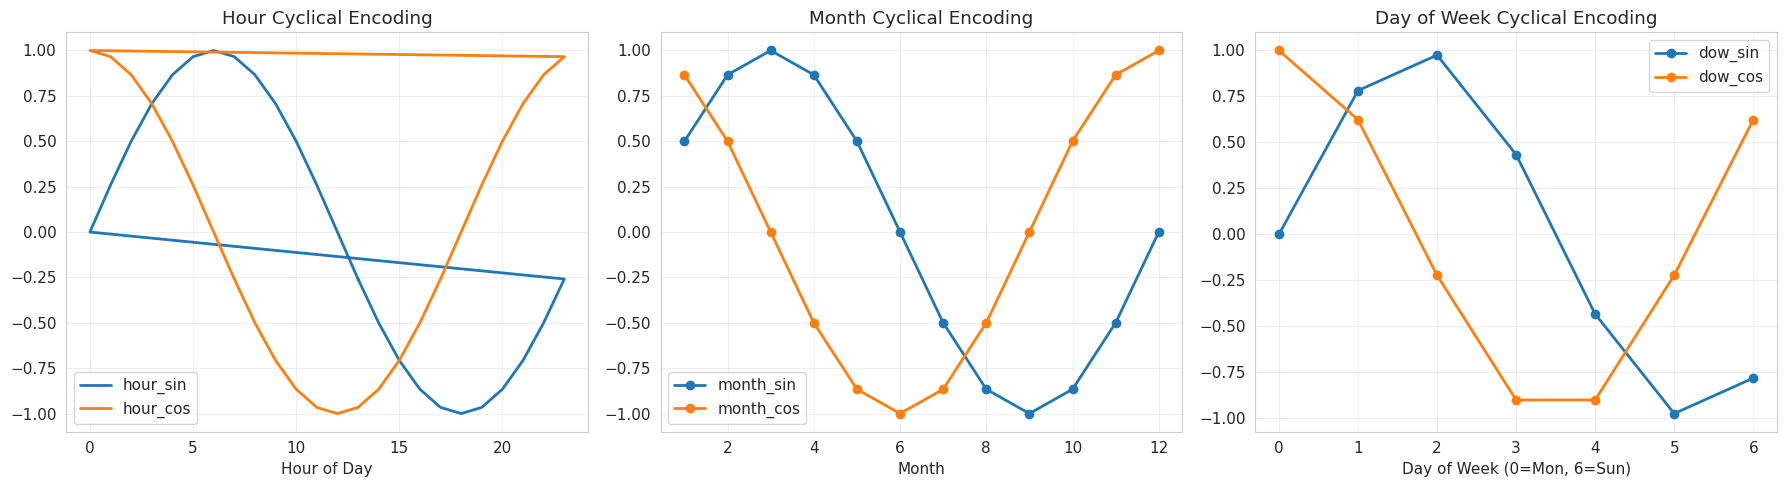

 MUTUAL INFORMATION (catches non-linear relationships)
Clean rows for MI calculation: 123,238

--- MUTUAL INFORMATION: Site_Demand ---
  hour                                0.4272  █████████████████████████
  hour_cos                            0.3947  ███████████████████████
  Global_Horizontal_Radiation         0.3874  ███████████████████████
  Radiation_Global_Tilted             0.3705  ██████████████████████
  Diffuse_Horizontal_Radiation        0.3627  █████████████████████
  Radiation_Diffuse_Tilted            0.3613  █████████████████████
  Weather_Temperature_Celsius         0.2477  ██████████████
  month                               0.1623  █████████
  day_of_week                         0.1127  ██████
  dow_sin                             0.1126  ██████
  Weather_Relative_Humidity           0.1061  ██████
  hour_sin                            0.0906  █████
  is_weekend                          0.0896  █████
  month_cos                           0.0844  █████
  month_sin     

In [10]:
# ============================================================
# CELL 10: CYCLICAL ENCODING & MUTUAL INFORMATION
# ============================================================
from sklearn.feature_selection import mutual_info_regression

# Cyclical encoding
df_eda['hour_sin']  = np.sin(2 * np.pi * df_eda['hour'] / 24)
df_eda['hour_cos']  = np.cos(2 * np.pi * df_eda['hour'] / 24)
df_eda['month_sin'] = np.sin(2 * np.pi * df_eda['month'] / 12)
df_eda['month_cos'] = np.cos(2 * np.pi * df_eda['month'] / 12)
df_eda['dow_sin']   = np.sin(2 * np.pi * df_eda['day_of_week'] / 7)
df_eda['dow_cos']   = np.cos(2 * np.pi * df_eda['day_of_week'] / 7)

# Visualize cyclical encoding
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sample_24h = df_eda.iloc[:288]  # 24 hours
axes[0].plot(sample_24h.index.hour, sample_24h['hour_sin'], label='hour_sin', linewidth=2)
axes[0].plot(sample_24h.index.hour, sample_24h['hour_cos'], label='hour_cos', linewidth=2)
axes[0].set_xlabel('Hour of Day')
axes[0].set_title('Hour Cyclical Encoding')
axes[0].legend()
axes[0].grid(alpha=0.3)

month_sample = df_eda.groupby('month').first()[['month_sin', 'month_cos']]
axes[1].plot(month_sample.index, month_sample['month_sin'], 'o-', label='month_sin', linewidth=2)
axes[1].plot(month_sample.index, month_sample['month_cos'], 'o-', label='month_cos', linewidth=2)
axes[1].set_xlabel('Month')
axes[1].set_title('Month Cyclical Encoding')
axes[1].legend()
axes[1].grid(alpha=0.3)

dow_sample = df_eda.groupby('day_of_week').first()[['dow_sin', 'dow_cos']]
axes[2].plot(dow_sample.index, dow_sample['dow_sin'], 'o-', label='dow_sin', linewidth=2)
axes[2].plot(dow_sample.index, dow_sample['dow_cos'], 'o-', label='dow_cos', linewidth=2)
axes[2].set_xlabel('Day of Week (0=Mon, 6=Sun)')
axes[2].set_title('Day of Week Cyclical Encoding')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/eda_cyclical.png', dpi=120, bbox_inches='tight')
plt.show()

# Feature Importance via Mutual Information
print("="*70)
print(" MUTUAL INFORMATION (catches non-linear relationships)")
print("="*70)

# Όλα τα candidate features
all_features = [
    'Weather_Temperature_Celsius', 'Weather_Relative_Humidity',
    'Global_Horizontal_Radiation', 'Diffuse_Horizontal_Radiation',
    'Radiation_Global_Tilted', 'Radiation_Diffuse_Tilted',
    'Weather_Daily_Rainfall',
    'hour', 'hour_sin', 'hour_cos',
    'day_of_week', 'dow_sin', 'dow_cos', 'is_weekend',
    'month', 'month_sin', 'month_cos'
]

# Καθαρό dataset για MI calculation
df_clean = df_eda[all_features + ['Site_Demand', 'PV_Power']].dropna()
print(f"Clean rows for MI calculation: {len(df_clean):,}")

# MI για Site_Demand
print(f"\n--- MUTUAL INFORMATION: Site_Demand ---")
mi_demand = mutual_info_regression(df_clean[all_features], df_clean['Site_Demand'],
                                    random_state=42)
mi_demand_df = pd.DataFrame({
    'Feature': all_features,
    'MI_Score': mi_demand
}).sort_values('MI_Score', ascending=False)

for _, row in mi_demand_df.iterrows():
    bar_length = int(row['MI_Score'] * 60)
    bar = '█' * bar_length
    print(f"  {row['Feature']:<35} {row['MI_Score']:.4f}  {bar}")

# MI για PV_Power
print(f"\n--- MUTUAL INFORMATION: PV_Power ---")
mi_pv = mutual_info_regression(df_clean[all_features], df_clean['PV_Power'],
                               random_state=42)
mi_pv_df = pd.DataFrame({
    'Feature': all_features,
    'MI_Score': mi_pv
}).sort_values('MI_Score', ascending=False)

for _, row in mi_pv_df.iterrows():
    bar_length = int(row['MI_Score'] * 60)
    bar = '█' * bar_length
    print(f"  {row['Feature']:<35} {row['MI_Score']:.4f}  {bar}")

In [11]:
# ============================================================
# CELL 11: ΣΥΝΟΛΙΚΗ ΣΥΝΟΨΗ EDA
# ============================================================

print("="*78)
print(" EXPLORATORY DATA ANALYSIS - ΤΕΛΙΚΗ ΣΥΝΟΨΗ ΕΥΡΗΜΑΤΩΝ")
print(" DKP Microgrid Dataset (Dec 2023 - Sep 2025)")
print("="*78)

# ------------------------------------------------------------
# 1. DATASET OVERVIEW
# ------------------------------------------------------------
print("\n" + "="*78)
print(" 1. DATASET OVERVIEW")
print("="*78)

total_obs = len(df_eda)
duration_days = (df_eda.index.max() - df_eda.index.min()).days
sampling_min = 5

print(f"""
Πηγή Δεδομένων:        DKP Microgrid, Alice Springs, Australia
Χρονική Περίοδος:      {df_eda.index.min().strftime('%Y-%m-%d')} έως {df_eda.index.max().strftime('%Y-%m-%d')}
Διάρκεια:              {duration_days} ημέρες ({duration_days/365:.1f} χρόνια)
Sampling Resolution:   {sampling_min} λεπτά
Συνολικές Παρατηρήσεις: {total_obs:,}
Συστήματα:             4 (PV, Site Demand, BESS, Grid)
""")

# ------------------------------------------------------------
# 2. ΣΥΣΤΗΜΑΤΑ ΚΑΙ ΧΑΡΑΚΤΗΡΙΣΤΙΚΑ
# ------------------------------------------------------------
print("="*78)
print(" 2. ΧΑΡΑΚΤΗΡΙΣΤΙΚΑ ΣΥΣΤΗΜΑΤΩΝ")
print("="*78)

systems_summary = pd.DataFrame({
    'System': ['PV (Microgrid Total)', 'Site Demand', 'Grid', 'BESS'],
    'Min (kW)':  [f"{df_eda['PV_Power'].min():.1f}",
                  f"{df_eda['Site_Demand'].min():.1f}",
                  f"{df_eda['Grid_Power'].min():.1f}",
                  f"{df_eda['BESS_Power'].min():.1f}"],
    'Max (kW)':  [f"{df_eda['PV_Power'].max():.1f}",
                  f"{df_eda['Site_Demand'].max():.1f}",
                  f"{df_eda['Grid_Power'].max():.1f}",
                  f"{df_eda['BESS_Power'].max():.1f}"],
    'Mean (kW)': [f"{df_eda['PV_Power'].mean():.1f}",
                  f"{df_eda['Site_Demand'].mean():.1f}",
                  f"{df_eda['Grid_Power'].mean():.1f}",
                  f"{df_eda['BESS_Power'].mean():.1f}"]
})
print("\n" + systems_summary.to_string(index=False))

print(f"""
BESS State of Charge:
  Range:    {df_eda['BESS_SoC'].min():.1f}% - {df_eda['BESS_SoC'].max():.1f}%
  Mean:     {df_eda['BESS_SoC'].mean():.1f}%
  Median:   {df_eda['BESS_SoC'].median():.1f}%

Παρατήρηση: Η μπαταρία λειτουργεί συχνά σε χαμηλό SoC (deep discharge),
γεγονός που υποδηλώνει υπό-βέλτιστη χρήση από τον υπάρχοντα EMS.
Αυτό αποτελεί ευκαιρία βελτίωσης για τον προτεινόμενο EMS αλγόριθμο.
""")

# ------------------------------------------------------------
# 3. TEMPORAL PATTERNS
# ------------------------------------------------------------
print("="*78)
print(" 3. TEMPORAL PATTERNS (SITE DEMAND)")
print("="*78)

hourly_demand = df_eda.groupby('hour')['Site_Demand'].mean()
weekday_avg = df_eda[df_eda['is_weekend'] == 0]['Site_Demand'].mean()
weekend_avg = df_eda[df_eda['is_weekend'] == 1]['Site_Demand'].mean()

print(f"""
Daily Pattern (Office Building Profile):
  Min hourly avg:    {hourly_demand.min():.1f} kW (hour {hourly_demand.idxmin()})
  Max hourly avg:    {hourly_demand.max():.1f} kW (hour {hourly_demand.idxmax()})
  Peak/Off ratio:    {hourly_demand.max()/hourly_demand.min():.1f}x

Weekly Pattern:
  Weekday avg:       {weekday_avg:.1f} kW
  Weekend avg:       {weekend_avg:.1f} kW
  Weekday/Weekend:   {weekday_avg/weekend_avg:.2f}x

Συμπέρασμα: Καθαρό 'commercial office building' pattern με σημαντική
διαφοροποίηση μεταξύ εργάσιμων ωρών (09:00-16:00) και υπολοίπων.
""")

# ------------------------------------------------------------
# 4. SEASONAL PATTERNS
# ------------------------------------------------------------
print("="*78)
print(" 4. SEASONAL PATTERNS (Southern Hemisphere)")
print("="*78)

print(f"""
PV Generation:
  Καλοκαίρι (Dec-Feb):   {df_eda[df_eda['month'].isin([12,1,2])]['PV_Power'].mean():.1f} kW (peak season)
  Χειμώνας (Jun-Aug):    {df_eda[df_eda['month'].isin([6,7,8])]['PV_Power'].mean():.1f} kW

Site Demand:
  Καλοκαίρι (Dec-Feb):   {df_eda[df_eda['month'].isin([12,1,2])]['Site_Demand'].mean():.1f} kW (A/C cooling peak)
  Χειμώνας (Jun-Aug):    {df_eda[df_eda['month'].isin([6,7,8])]['Site_Demand'].mean():.1f} kW

Temperature:
  Καλοκαίρι (Dec-Feb):   {df_eda[df_eda['month'].isin([12,1,2])]['Weather_Temperature_Celsius'].mean():.1f} °C
  Χειμώνας (Jun-Aug):    {df_eda[df_eda['month'].isin([6,7,8])]['Weather_Temperature_Celsius'].mean():.1f} °C

Συμπέρασμα: Το demand είναι HVAC-driven (cooling > heating). Peak demand
συμπίπτει με peak PV generation, που είναι ευνοϊκό για τη χρήση μπαταρίας.
""")

# ------------------------------------------------------------
# 5. PEARSON vs MUTUAL INFORMATION COMPARISON
# ------------------------------------------------------------
print("="*78)
print(" 5. ΣΥΓΚΡΙΣΗ FEATURE IMPORTANCE METHODS")
print("="*78)

print(f"""
ΚΡΙΣΙΜΟ ΕΥΡΗΜΑ: Η Pearson correlation αποτυγχάνει σε μη-γραμμικές σχέσεις.

Παράδειγμα (Site_Demand vs hour):
  Pearson Correlation:   ~0.02  (αμελητέα γραμμική σχέση)
  Mutual Information:    0.43   (ισχυρή μη-γραμμική σχέση)

Συμπέρασμα: Για temporal & cyclical features, η Mutual Information είναι
απαραίτητο εργαλείο επιλογής features. Η αποκλειστική χρήση Pearson θα
οδηγούσε σε λανθασμένη αποκλεισμό κρίσιμων features.
""")

# ------------------------------------------------------------
# 6. DATA QUALITY ISSUES
# ------------------------------------------------------------
print("="*78)
print(" 6. DATA QUALITY ISSUES & ΑΝΤΙΜΕΤΩΠΙΣΗ")
print("="*78)

print(f"""
Εντοπισμένα Προβλήματα:

[1] Wind_Speed: 100% missing
    -> Drop από όλα τα μοντέλα.

[2] Wind_Direction: εκτός φυσικού εύρους (-12° έως 80°)
    -> Drop από όλα τα μοντέλα.

[3] Site_Demand αρνητικές τιμές: 1,147 (~0.6%)
    -> Έχουν αντικατασταθεί με NaN (φυσικά αδύνατες τιμές).

[4] Weather_Relative_Humidity > 100%: 3,683 παρατηρήσεις
    -> Clipped στο [0, 100] εύρος.

[5] Outage period: ορατό από ~8 Μαρτίου 2024 (επίπεδες τιμές)
    -> 17 ημέρες (2.7%) με < 200 records, πιθανώς σε αυτή την περίοδο.

[6] Multicollinearity:
    GHI vs Radiation_Global_Tilted: corr = 0.98
    DHI vs Radiation_Diffuse_Tilted: corr = 0.92
    -> Επιλογή ενός από κάθε ζεύγος για να αποφευχθεί redundancy.

[7] Missing values μετεωρολογικών δεδομένων: ~20%
    -> Θα αντιμετωπιστούν με KNN imputation στο preprocessing.
""")

# ------------------------------------------------------------
# 7. ΤΕΛΙΚΗ ΕΠΙΛΟΓΗ FEATURES
# ------------------------------------------------------------
print("="*78)
print(" 7. ΤΕΛΙΚΗ ΕΠΙΛΟΓΗ FEATURES (βάσει Mutual Information)")
print("="*78)

print("""
=== LOAD FORECASTING MODEL ===

Top Tier (must-have):
  1. hour_sin + hour_cos  (cyclical encoding - MI 0.39 + 0.09)
  2. Global_Horizontal_Radiation (proxy for daylight/activity - MI 0.39)
  3. Weather_Temperature_Celsius (HVAC-driven demand - MI 0.25)

Mid Tier (recommended):
  4. month_sin + month_cos (seasonality)
  5. dow_sin + dow_cos (weekly cycle)
  6. Weather_Relative_Humidity (comfort/HVAC - MI 0.11)
  7. Diffuse_Horizontal_Radiation (cloudy conditions)

Lag Features (να προστεθούν στο modeling):
  8. Demand_lag_1h (κατανάλωση πριν 1 ώρα)
  9. Demand_lag_24h (ίδια ώρα χθες)
  10. Demand_lag_168h (ίδια ώρα την περασμένη εβδομάδα)

Excluded:
  - Wind_Speed, Wind_Direction (data quality)
  - Radiation_Global_Tilted (multicollinearity με GHI)
  - is_weekend (redundant με dow features)
  - Weather_Daily_Rainfall (χαμηλό MI = 0.03)


=== PV FORECASTING MODEL (microgrid) ===

Top Tier (must-have):
  1. Global_Horizontal_Radiation (κυρίαρχο - MI 1.34)
  2. hour_sin + hour_cos (ώρα ηλιακής δραστηριότητας - MI 0.90 + 0.33)
  3. Diffuse_Horizontal_Radiation (cloudy conditions - MI 0.95)

Mid Tier (recommended):
  4. Weather_Temperature_Celsius (panel efficiency - MI 0.20)
  5. month_sin + month_cos (sun angle seasonality)
  6. Weather_Relative_Humidity (haze indicator - MI 0.18)

Lag Features:
  7. PV_lag_5min, PV_lag_15min (recent generation)

Excluded:
  - Wind_Speed, Wind_Direction (data quality)
  - Radiation_Global_Tilted (multicollinearity με GHI)
  - Radiation_Diffuse_Tilted (multicollinearity με DHI)
  - day_of_week, dow_sin, dow_cos, is_weekend (MI ≈ 0)
  - Weather_Daily_Rainfall (χαμηλό MI)
""")

# ------------------------------------------------------------
# 8. ΠΡΟΤΕΙΝΟΜΕΝΑ ΕΠΟΜΕΝΑ ΒΗΜΑΤΑ
# ------------------------------------------------------------
print("="*78)
print(" 8. ΠΡΟΤΕΙΝΟΜΕΝΑ ΕΠΟΜΕΝΑ ΒΗΜΑΤΑ")
print("="*78)

print("""
Stage 1: Load Forecasting Model
  - CPU notebook: XGBoost, Random Forest, SVR
  - GPU notebook: LSTM, CNN-LSTM, Bi-LSTM
  - Target: Site_Demand (30-min ahead prediction)

Stage 2: PV Forecasting Model (Microgrid)
  - CPU notebook: XGBoost, Random Forest, SVR
  - GPU notebook: LSTM, CNN-LSTM, Bi-LSTM
  - Target: PV_Power (30-min ahead prediction)

Stage 3: Energy Management System (EMS)
  - Rule-based controller με χρήση των δύο forecasting models
  - Λογική: ΔP = Predicted_PV - Predicted_Load
  - Battery operation με safety limits (SoC: 20%-90%)
  - Aξιολόγηση: σύγκριση Grid_Import με/χωρίς προτεινόμενο EMS

Stage 4: Performance Evaluation
  - Σύγκριση όλων των μοντέλων (MAE, RMSE, R²)
  - Συγκριτική αξιολόγηση EMS scenarios
  - Quantification grid dependency reduction
""")

print("="*78)
print(" EDA ΟΛΟΚΛΗΡΩΘΗΚΕ ΕΠΙΤΥΧΩΣ")
print("="*78)

 EXPLORATORY DATA ANALYSIS - ΤΕΛΙΚΗ ΣΥΝΟΨΗ ΕΥΡΗΜΑΤΩΝ
 DKP Microgrid Dataset (Dec 2023 - Sep 2025)

 1. DATASET OVERVIEW

Πηγή Δεδομένων:        DKP Microgrid, Alice Springs, Australia
Χρονική Περίοδος:      2023-12-07 έως 2025-09-04
Διάρκεια:              636 ημέρες (1.7 χρόνια)
Sampling Resolution:   5 λεπτά
Συνολικές Παρατηρήσεις: 182,293
Συστήματα:             4 (PV, Site Demand, BESS, Grid)

 2. ΧΑΡΑΚΤΗΡΙΣΤΙΚΑ ΣΥΣΤΗΜΑΤΩΝ

              System Min (kW) Max (kW) Mean (kW)
PV (Microgrid Total)      0.0    471.2      57.7
         Site Demand      0.0    483.2      82.8
                Grid   -184.5    349.1      33.1
                BESS   -183.4    196.8      -1.9

BESS State of Charge:
  Range:    0.0% - 94.9%
  Mean:     28.4%
  Median:   14.6%

Παρατήρηση: Η μπαταρία λειτουργεί συχνά σε χαμηλό SoC (deep discharge),
γεγονός που υποδηλώνει υπό-βέλτιστη χρήση από τον υπάρχοντα EMS.
Αυτό αποτελεί ευκαιρία βελτίωσης για τον προτεινόμενο EMS αλγόριθμο.

 3. TEMPORAL PATTERNS (SITE DEMAN